# How to use the temporal logic ?
First import maboss and the temporal_logic module

In [1]:
import sys
import os

# this is needed only if maboss is not seen by Jupyter
path_dev = os.path.expanduser("~/Documents/MaBoSS/pyMaBoSS")
if path_dev not in sys.path:
    sys.path.insert(0, path_dev)

import maboss
from maboss import temporal_logic as tl

ipylab module is not installed, menus and toolbar are disabled.


# Step 1 - Now you can run a simulation
Here we are going to use the BRAF model. I am using the seed "100" for reproductibility.

In [5]:
BRAF_model = maboss.load("BRAF_Model.bnd", "BRAF_Model.cfg")
BRAF_model.update_parameters(seed_pseudorandom=100)
wt_BRAF = BRAF_model.run()
print("simulation done !")

simulation done !


# Step 2 - Prepare your list of questions.
My questions for this example are going to be simple queries at first :
- The moments where node AKT being greater or equal to 0.1
- The moments where state AKT--CRAF--GRB2--FRS2--FGF--FGFR2 being greater or equal to 0.5
- The moments where node proliferation_b1 being greater or equal to 0.1 while proliferation_b2 or BRAF is active

In [6]:
queries = [ "P(node:AKT) >= 0.4" , "P(state:AKT) >= 0.0000001" , "P(node:Proliferation_b1) >= 0.1 [ Proliferation_b2 | BRAF ]"]

Then you need to ask `tl` to evaluate the queries. It will return a list of dataframe.
It might take some time depending on the size of the results

In [7]:
results = tl.MaBoSSEvaluator.querying(queries,wt_BRAF)

Query "P(node:AKT) >= 0.4" parsed successfully !
Query P(node:AKT) >= 0.4 evaluated successfully !
Query "P(state:AKT) >= 0.0000001" parsed successfully !
Query P(state:AKT) >= 0.0000001 evaluated successfully !
Query "P(node:Proliferation_b1) >= 0.1 [ Proliferation_b2 | BRAF ]" parsed successfully !
Query P(node:Proliferation_b1) >= 0.1 [ Proliferation_b2 | BRAF ] evaluated successfully !


# Step 3 - The results
The object **results** is a list of dataframes. So we can look at each of them, if not too big, like this :

In [8]:
print(results[0]) #for the first query

    Time       AKT
0    0.0  0.502381
1    0.5  0.497507
2    1.0  0.489130
3    1.5  0.483671
4    2.0  0.470416
5    2.5  0.460139
6    3.0  0.453194
7    3.5  0.441748
8    4.0  0.425900
9    4.5  0.417019
10   5.0  0.407337


And see here you only have the node AKT where it is greater or equal to 0.4

In [9]:
print(results[1]) #the second query

   Time       AKT
0   2.0  0.000182
1   2.5  0.000200
2   3.0  0.000200
3   3.5  0.000262
4   4.0  0.000248
5   4.5  0.000200
6   5.0  0.000051


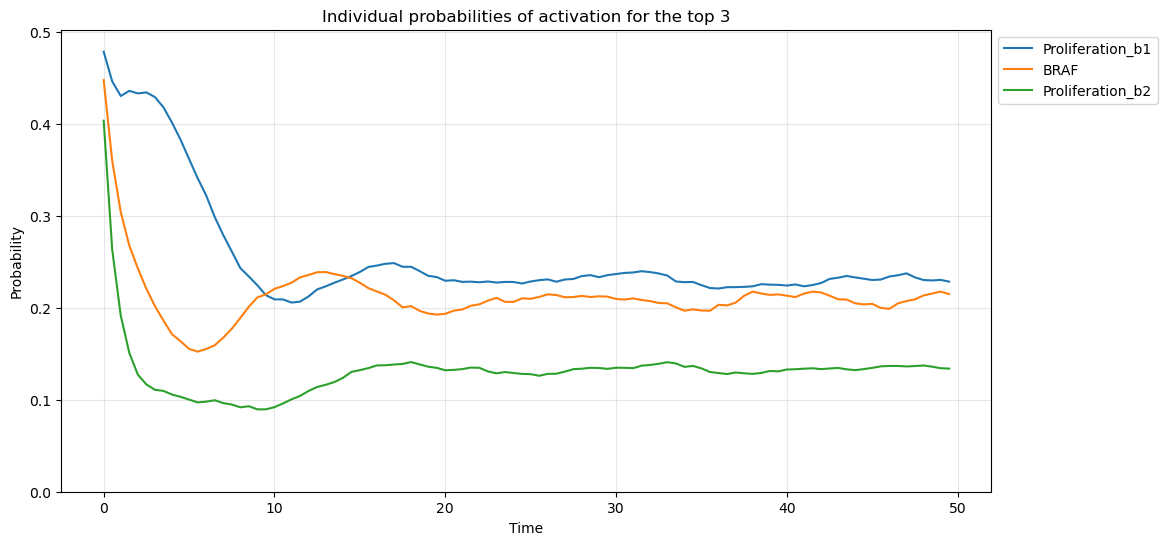

In [13]:
from maboss.temporal_logic import visualiser
results[2].viz.evolution_over_time(top=3)